In [25]:
!pip install plotly

POPULATION STATISTICS — GDP per Capita (constant 2015 US$)
  N (population size)  = 250
  μ (population mean)  =    16,527.84
  σ (population SD)    =    24,551.75
  Skewness             =       3.6424  ← severely right-skewed
  Shapiro-Wilk p       = 8.66e-23  ← non-normal
F1 SUMMARY — Empirical vs Theoretical Sampling Distribution
    n |    Emp. Mean | Theor. Mean (μ) |    Emp. SE | Theor. SE (σ/√n) |   Ratio
    2 |    16,236.40 |       16,527.84 |  16,626.04 |        17,360.71 |  0.9577
    5 |    16,665.78 |       16,527.84 |  10,803.35 |        10,979.88 |  0.9839
   15 |    16,532.45 |       16,527.84 |   6,301.42 |         6,339.24 |  0.9940
   30 |    16,569.36 |       16,527.84 |   4,524.87 |         4,482.52 |  1.0094
  100 |    16,526.29 |       16,527.84 |   2,490.01 |         2,455.18 |  1.0142
SQUARE ROOT LAW VERIFICATION  (Emp SE × √n should ≈ Population SD)
     Emp SE (σ̂/√n)  Theor SE (σ/√n)  Emp SE × √n  Population SD (σ)  Ratio (Emp/Theor)
n                       

C:\Users\User\AppData\Local\Temp\ipykernel_22556\2254065270.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


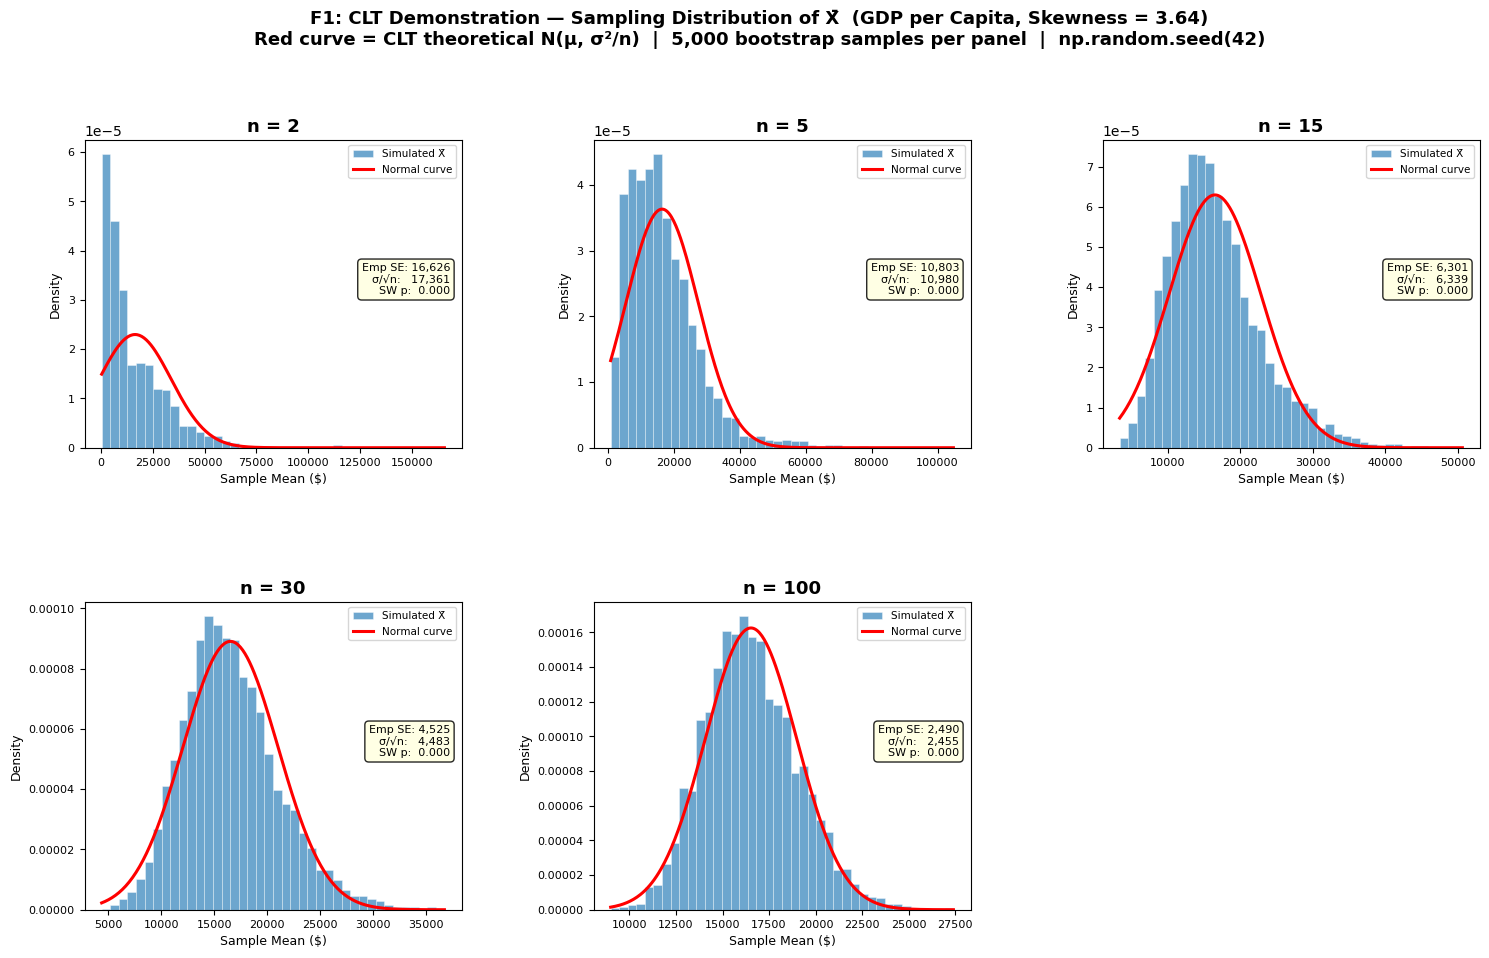

f1_clt_histograms.png saved
F2 — SAMPLE SIZE PLANNING
  Binary variable: B = 1 if life expectancy ≥ 73.84 yrs
  Observed p̂       = 0.5019
  Conservative p   = 0.5
  z_{α/2} (95%)  = 1.9600
  Target W = 0.06  →  E = W/2 = 0.03

  n = ⌈(z_{α/2}/E)² × p(1-p)⌉
    = ⌈(1.9600/0.03)² × 0.5 × 0.5⌉
    = ⌈4268.2876 × 0.25⌉
    = ⌈1067.0719⌉
    = 1068   ← minimum required n (conservative)

  Using observed p̂=0.5019: n = 1068

     W |   n (90%) |   n (95%) |   n (99%)
------------------------------------------
  0.02 |      6764 |      9604 |     16588
  0.04 |      1691 |      2401 |      4147
  0.06 |       752 |      1068 |      1844
  0.08 |       423 |       601 |      1037
  0.10 |       271 |       385 |       664
  0.12 |       188 |       267 |       461
  0.16 |       106 |       151 |       260
  0.20 |        68 |        97 |       166


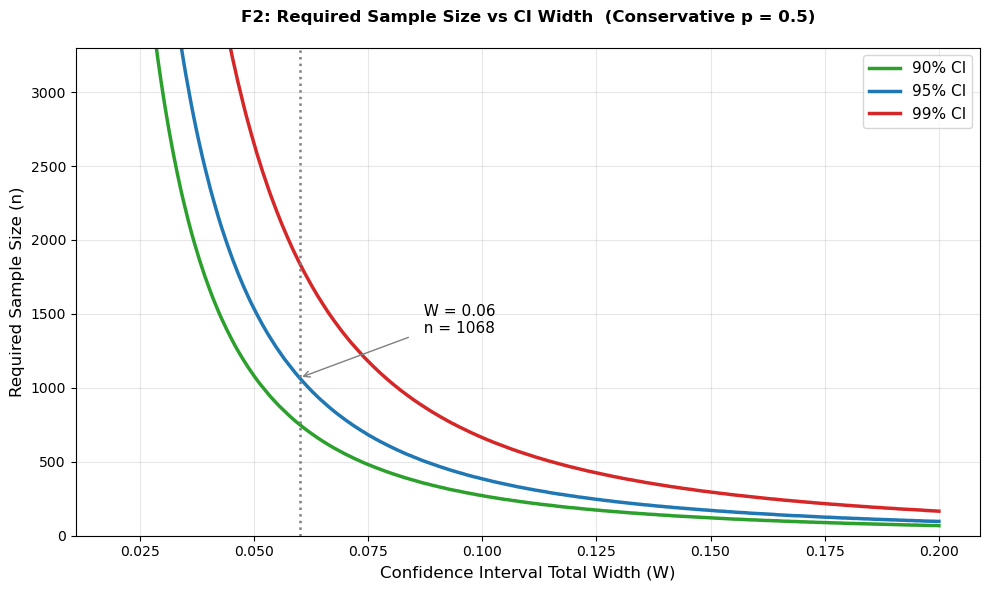

 f2_sample_size.png saved


In [42]:
# TASK F – The Central Limit Theorem and Sample Size Planning
# F1: CLT Demonstration

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Fix random seed for full reproducibility
np.random.seed(42)

# Load dataset
df = pd.read_csv("worldbank_complete_dataset.csv", na_values=[".."])
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

gdp_col  = "GDP per capita (constant 2015 US$)"
life_col = "Life expectancy at birth, total (years)"

# Population (all non-missing GDP values) 
# GDP per capita is deliberately chosen because it is severely
# right-skewed (skewness = 3.64), making it the ideal variable
# to demonstrate the CLT: the population itself is non-normal,
# yet the sampling distribution of X̄ converges to normality.
population = df[gdp_col].dropna().values
pop_mean   = np.mean(population)
pop_std    = np.std(population, ddof=0)   # σ = population SD (ddof=0)
pop_skew   = stats.skew(population)


print("POPULATION STATISTICS — GDP per Capita (constant 2015 US$)")

print(f"  N (population size)  = {len(population)}")
print(f"  μ (population mean)  = {pop_mean:>12,.2f}")
print(f"  σ (population SD)    = {pop_std:>12,.2f}")
print(f"  Skewness             = {pop_skew:>12.4f}  ← severely right-skewed")
print(f"  Shapiro-Wilk p       = {stats.shapiro(population)[1]:.2e}  ← non-normal")


# F1 — STEP 1: Simulate 5,000 sample means for each n

# Bootstrap sampling with replacement simulates the act of
# drawing repeated random samples from the population.
# For each sample size n, we compute 5,000 sample means X̄.
# The distribution of those 5,000 values IS the sampling
# distribution of X̄ for that particular n.

sample_sizes  = [2, 5, 15, 30, 100]
n_simulations = 5000
results = {}

for n in sample_sizes:
    results[n] = np.array([
        np.mean(np.random.choice(population, n, replace=True))
        for _ in range(n_simulations)
    ])


# F1 — STEP 2: Empirical vs Theoretical Summary Table

# CLT guarantees:  E[X̄] = μ  and  SE(X̄) = σ/√n
# We verify both claims empirically below.
# Ratio ≈ 1.00 across all n confirms the formula is exact.


print("F1 SUMMARY — Empirical vs Theoretical Sampling Distribution")

print(f"{'n':>5} | {'Emp. Mean':>12} | {'Theor. Mean (μ)':>15} | "
      f"{'Emp. SE':>10} | {'Theor. SE (σ/√n)':>16} | {'Ratio':>7}")

for n in sample_sizes:
    emp_mean = np.mean(results[n])
    emp_se   = np.std(results[n])
    theor_se = pop_std / np.sqrt(n)
    ratio    = emp_se / theor_se
    print(f"{n:>5} | {emp_mean:>12,.2f} | {pop_mean:>15,.2f} | "
          f"{emp_se:>10,.2f} | {theor_se:>16,.2f} | {ratio:>7.4f}")


# F1 — STEP 3: Square Root Law Verification

# The Square Root Law states SE = σ/√n.
# Equivalently: Emp SE × √n ≈ σ for all n.
# The table below verifies this empirically for all 5 sample sizes.


print("SQUARE ROOT LAW VERIFICATION  (Emp SE × √n should ≈ Population SD)")

rows_sq = []
for n in sample_sizes:
    se_emp   = np.std(results[n])
    se_theor = pop_std / np.sqrt(n)
    rows_sq.append({
        "n"                  : n,
        "Emp SE (σ̂/√n)"     : round(se_emp,   2),
        "Theor SE (σ/√n)"   : round(se_theor, 2),
        "Emp SE × √n"       : round(se_emp * np.sqrt(n), 2),
        "Population SD (σ)" : round(pop_std,  2),
        "Ratio (Emp/Theor)" : round(se_emp / se_theor, 4)
    })
sq_df = pd.DataFrame(rows_sq).set_index("n")
print(sq_df.to_string())
print(f"\n  ✔  'Emp SE × √n' ≈ σ = {pop_std:,.2f} for all n (confirms law)")
print(f"  ✔  Ratio ≈ 1.00 for all n (formula SE = σ/√n is empirically exact)")

print("\nSQUARE ROOT LAW — SE reduction across consecutive sample sizes:")
for i in range(len(sample_sizes) - 1):
    n1, n2 = sample_sizes[i], sample_sizes[i+1]
    se1, se2 = pop_std/np.sqrt(n1), pop_std/np.sqrt(n2)
    print(f"  n={n1:>3} → n={n2:>3}: SE {se1:>9,.2f} → {se2:>9,.2f}  "
          f"(factor = {se1/se2:.4f},  √({n2}/{n1}) = {np.sqrt(n2/n1):.4f})")


# F1 — STEP 4: CLT Histograms (matplotlib — no kaleido needed)

# Each panel shows the distribution of 5,000 sample means.
# Blue bars  = empirical sampling distribution
# Red curve  = CLT theoretical N(μ, σ²/n)
# As n grows, the bars align increasingly with the red curve,
# visually confirming CLT convergence regardless of population shape.

fig = plt.figure(figsize=(18, 10))
fig.suptitle(
    "F1: CLT Demonstration — Sampling Distribution of X̄  "
    "(GDP per Capita, Skewness = 3.64)\n"
    "Red curve = CLT theoretical N(μ, σ²/n)  |  "
    "5,000 bootstrap samples per panel  |  np.random.seed(42)",
    fontsize=13, fontweight="bold", y=1.01
)

gs        = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.35)
positions = [(0,0),(0,1),(0,2),(1,0),(1,1)]

for idx, n in enumerate(sample_sizes):
    r, c     = positions[idx]
    ax       = fig.add_subplot(gs[r, c])
    data     = results[n]
    theor_sd = pop_std / np.sqrt(n)
    emp_se   = np.std(data)
    sw_p     = stats.shapiro(data)[1]

    # Histogram — density=True so the y-axis is a probability density,
    # making the CLT normal PDF overlay directly comparable.
    ax.hist(data, bins=40, density=True,
            color="#1f77b4", alpha=0.65,
            edgecolor="white", linewidth=0.4,
            label="Simulated X̄")

    # CLT theoretical PDF: N(μ, σ²/n)
    x_pdf = np.linspace(data.min(), data.max(), 300)
    ax.plot(x_pdf, stats.norm.pdf(x_pdf, pop_mean, theor_sd),
            color="red", linewidth=2.2, label="Normal curve")

    ax.set_title(f"n = {n}", fontsize=13, fontweight="bold", pad=6)
    ax.set_xlabel("Sample Mean ($)", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7.5, loc="upper right")

    # Annotate each panel with key statistics
    ax.text(0.97, 0.60,
            f"Emp SE: {emp_se:,.0f}\n"
            f"σ/√n:   {theor_sd:,.0f}\n"
            f"SW p:  {sw_p:.3f}",
            transform=ax.transAxes, fontsize=8,
            va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.35",
                      facecolor="lightyellow", alpha=0.85))

# Hide unused 6th subplot slot
fig.add_subplot(gs[1, 2]).set_visible(False)

plt.tight_layout()
plt.savefig("f1_clt_histograms.png", dpi=150, bbox_inches="tight")
plt.show()
print("f1_clt_histograms.png saved")


# F2 — SAMPLE SIZE PLANNING

# Variable: B = 1 if life expectancy ≥ median, 0 otherwise.
# Estimand: population proportion p = P(B = 1).
# Requirement: 95% CI with total width W ≤ 0.06 (E = 0.03).
#
# Formula derivation:
#   95% CI for proportion:  p̂ ± z_{0.025} × √(p(1-p)/n)
#   Set half-width = E:     E = z_{0.025} × √(p(1-p)/n)
#   Solve for n:            n = ⌈ (z_{0.025}/E)² × p(1-p) ⌉

df_f2       = df[[life_col]].dropna().copy()
median_life = df_f2[life_col].median()
df_f2["B"]  = (df_f2[life_col] >= median_life).astype(int)
p_obs       = df_f2["B"].mean()
p_cons      = 0.5       # maximises p(1-p) = 0.25 — conservative bound

W, E = 0.06, 0.03
z_90 = stats.norm.ppf(0.95)    # 1.6449
z_95 = stats.norm.ppf(0.975)   # 1.9600
z_99 = stats.norm.ppf(0.995)   # 2.5758

def min_n(z, p, E):
    """Minimum sample size: n = ceil( (z_{α/2}/E)^2 × p(1-p) )"""
    return int(np.ceil((z / E)**2 * p * (1 - p)))

n_cons = min_n(z_95, p_cons, E)
n_obs  = min_n(z_95, p_obs,  E)


print("F2 — SAMPLE SIZE PLANNING")

print(f"  Binary variable: B = 1 if life expectancy ≥ {median_life:.2f} yrs")
print(f"  Observed p̂       = {p_obs:.4f}")
print(f"  Conservative p   = {p_cons}")
print(f"  z_{{α/2}} (95%)  = {z_95:.4f}")
print(f"  Target W = {W}  →  E = W/2 = {E}")
print(f"\n  n = ⌈(z_{{α/2}}/E)² × p(1-p)⌉")
print(f"    = ⌈({z_95:.4f}/{E})² × {p_cons} × {p_cons}⌉")
print(f"    = ⌈{(z_95/E)**2:.4f} × 0.25⌉")
print(f"    = ⌈{(z_95/E)**2*0.25:.4f}⌉")
print(f"    = {n_cons}   ← minimum required n (conservative)")
print(f"\n  Using observed p̂={p_obs:.4f}: n = {n_obs}")

print(f"\n{'W':>6} | {'n (90%)':>9} | {'n (95%)':>9} | {'n (99%)':>9}")
print("-" * 42)
for w in [0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.16, 0.20]:
    print(f"{w:>6.2f} | {min_n(z_90,p_cons,w/2):>9} | "
          f"{min_n(z_95,p_cons,w/2):>9} | {min_n(z_99,p_cons,w/2):>9}")

# F2 Plot
widths = np.linspace(0.02, 0.20, 300)
z_vals = {"90% CI": z_90, "95% CI": z_95, "99% CI": z_99}
colors = {"90% CI": "#2ca02c", "95% CI": "#1f77b4", "99% CI": "#d62728"}

fig2, ax2 = plt.subplots(figsize=(10, 6))
for level, z in z_vals.items():
    ax2.plot(widths, [min_n(z, p_cons, w/2) for w in widths],
             color=colors[level], linewidth=2.5, label=level)

ax2.axvline(x=0.06, color="gray", linestyle=":", linewidth=1.8)
ax2.annotate(f"  W = 0.06\n  n = {n_cons}",
             xy=(0.06, n_cons), xytext=(0.085, n_cons + 300),
             fontsize=11, arrowprops=dict(arrowstyle="->", color="gray"))
ax2.set_xlabel("Confidence Interval Total Width (W)", fontsize=12)
ax2.set_ylabel("Required Sample Size (n)", fontsize=12)
ax2.set_title(
    "F2: Required Sample Size vs CI Width  (Conservative p = 0.5)\n",
    fontsize=12, fontweight="bold")
ax2.legend(fontsize=11)
ax2.set_ylim(0, 3300)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("f2_sample_size.png", dpi=150, bbox_inches="tight")
plt.show()
print(" f2_sample_size.png saved")
